# 2. Volatility & Correlation

This notebook estimates the volatility, covariance, and correlation characteristics of the portfolio's constituent assets.

These estimates provide the statistical foundation for portfolio risk measurement and are subsequently used in the Parametric VaR and Monte Carlo VaR models.

The analysis covers:

1. Historical volatility
2. Rolling volatility
3. Covariance
4. Correlation
5. EWMA volatility
6. Comparison of volatility estimation methodologies

In [1]:

import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from project_01_market_risk_engine.src.data import download_prices

In [2]:
TICKERS = [
    "SPY",
    "QQQ",
    "IWM",
    "TLT",
    "GLD"
]

START_DATE = "2015-01-01"
END_DATE = "2026-01-01"

In [3]:
prices = download_prices(
    tickers=TICKERS,
    start=START_DATE,
    end=END_DATE
)

returns = prices.pct_change().dropna()

[*********************100%***********************]  5 of 5 completed


## 1. Historical Volatility

Historical volatility is estimated as the sample standard deviation of daily returns.

Annualized volatility is calculated as:

σannual = σdaily × √252

This provides a baseline measure of the unconditional volatility of each asset over the full historical sample.

In [4]:
daily_volatility = returns.std()
annualized_volatility = daily_volatility*np.sqrt(252)
volatility_table = pd.DataFrame({
    "Daily Volatility":daily_volatility,
    "Annualized Volatility" : annualized_volatility
})
volatility_table

,Daily Volatility,Annualized Volatility
Ticker,,
GLD,0.009290,0.147472
IWM,0.014195,0.225335
QQQ,0.013847,0.219817
SPY,0.011208,0.177925
TLT,0.009474,0.150397


In [5]:

annualized_volatility

Ticker
GLD    0.147472
IWM    0.225335
QQQ    0.219817
SPY    0.177925
TLT    0.150397
dtype: float64

## 2. Rolling Volatility

Rolling volatility allows changes in the market risk environment to be observed over time.

A 60-trading-day rolling window is used to estimate annualized volatility. Unlike full-sample historical volatility, this measure adapts as older observations leave the estimation window and newer observations enter it.

This allows periods of elevated and declining market volatility to be identified.

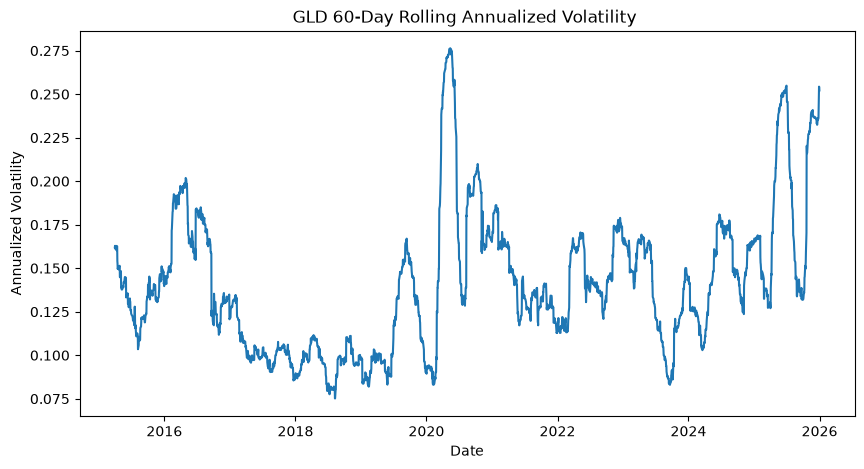

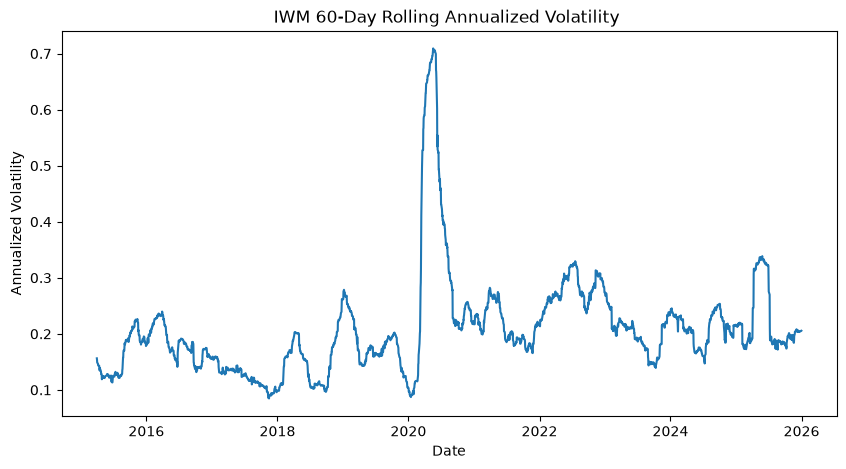

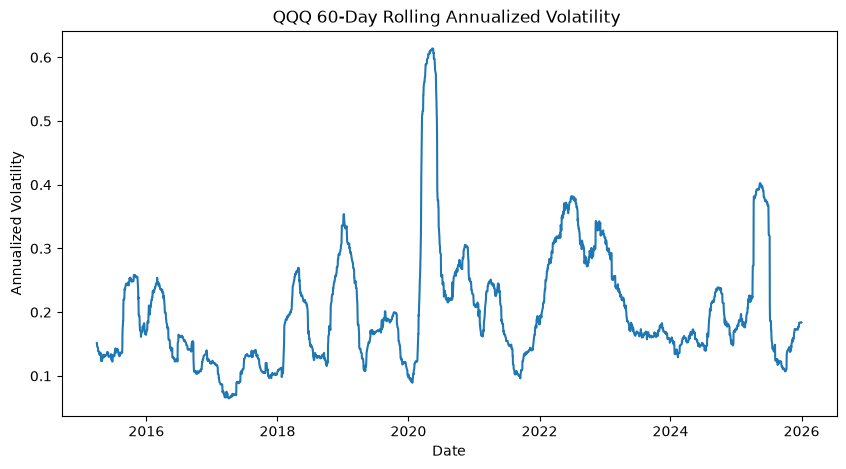

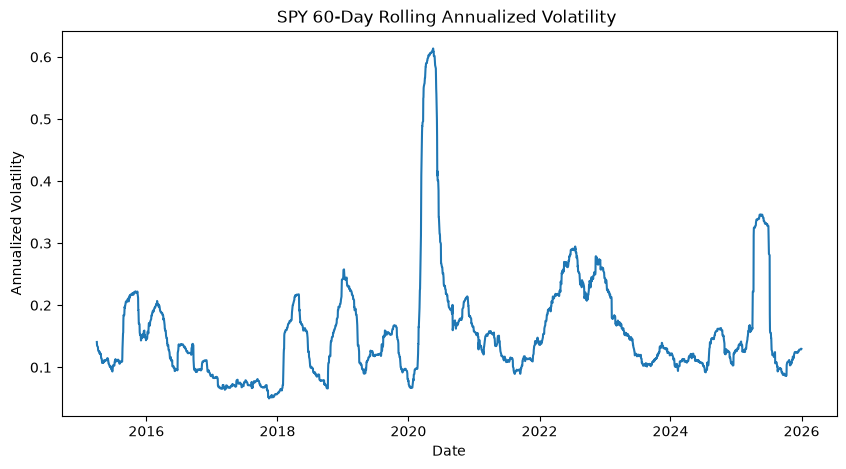

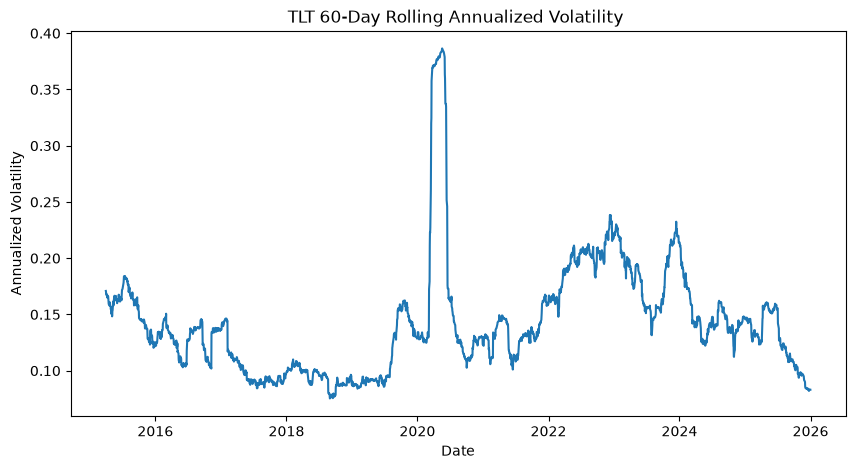

In [6]:
rolling_volatility_table = returns.rolling(window=60).std()

for ticker in returns.columns:
    plt.figure(figsize=(10,5))
    plt.plot(rolling_volatility_table[ticker]*np.sqrt(252))
    plt.title(f"{ticker} 60-Day Rolling Annualized Volatility "),
    plt.xlabel("Date"),
    plt.ylabel("Annualized Volatility")
    plt.show()

## 3. Covariance Matrix

The covariance matrix measures the joint movement of asset returns.

The diagonal elements represent individual return variances, while the off-diagonal elements represent pairwise covariance.

The covariance matrix is a key input to portfolio volatility:

σₚ = √(wᵀΣw)

where **w** represents portfolio weights and **Σ** represents the covariance matrix.

In [7]:
covariance_matrix = returns.cov()
covariance_matrix

Ticker,GLD,IWM,QQQ,SPY,TLT
Ticker,,,,,
GLD,0.000086,0.000006,0.000007,0.000005,0.000025
IWM,0.000006,0.000201,0.000151,0.000138,-0.000022
QQQ,0.000007,0.000151,0.000192,0.000145,-0.000017
SPY,0.000005,0.000138,0.000145,0.000126,-0.000020
TLT,0.000025,-0.000022,-0.000017,-0.000020,0.000090


In [8]:
annualized_covariance = covariance_matrix * 252
annualized_covariance

Ticker,GLD,IWM,QQQ,SPY,TLT
Ticker,,,,,
GLD,0.021748,0.001547,0.001693,0.001160,0.006232
IWM,0.001547,0.050776,0.038101,0.034770,-0.005535
QQQ,0.001693,0.038101,0.048320,0.036521,-0.004340
SPY,0.001160,0.034770,0.036521,0.031657,-0.004950
TLT,0.006232,-0.005535,-0.004340,-0.004950,0.022619


## 4. Correlation Matrix

Correlation standardizes covariance to a range between -1 and +1.

Unlike covariance, correlation is independent of the scale of the individual
assets and therefore makes it easier to compare relationships across assets.

In [9]:
correlation_matrix = returns.corr()
correlation_matrix

Ticker,GLD,IWM,QQQ,SPY,TLT
Ticker,,,,,
GLD,1.000000,0.046555,0.052229,0.044217,0.280961
IWM,0.046555,1.000000,0.769219,0.867231,-0.163326
QQQ,0.052229,0.769219,1.000000,0.933781,-0.131283
SPY,0.044217,0.867231,0.933781,1.000000,-0.184989
TLT,0.280961,-0.163326,-0.131283,-0.184989,1.000000


### Interpretation

The correlation matrix indicates substantial dependence among the equity assets. SPY, QQQ, and IWM exhibit strong positive correlations, with correlations of approximately 0.93, 0.77, and 0.87 across the relevant pairs.

This demonstrates that holding multiple equity ETFs does not necessarily provide proportionate diversification because they retain significant common market exposure.

TLT exhibits mildly negative correlations with the equity assets, while GLD has relatively low correlation with SPY and QQQ. These characteristics may provide greater diversification benefits within a multi-asset portfolio.

## 5. EWMA Volatility

Historical volatility assigns equal weight to observations across the estimation sample. EWMA volatility gives greater weight to recent observations through an exponential decay factor.

The EWMA approach is useful when recent market conditions are expected to contain more information about current risk than older observations.

The EWMA variance is calculated as:

σ²ₜ = λσ²ₜ₋₁ + (1 − λ)r²ₜ₋₁

A decay factor of λ = 0.94 is used for the initial implementation.

In [10]:
lambda_ = 0.94

ewma_table = pd.DataFrame(index=returns.index)

for ticker in returns.columns:

    variance_col = f"{ticker}_variance"
    volatility_col = f"{ticker}_annualized_volatility"

    # 1. Initialize columns with NaN
    ewma_table[variance_col] = np.nan
    ewma_table[volatility_col] = np.nan

    # 2. Get the column number positions 
    var_col_idx = ewma_table.columns.get_loc(variance_col)
    vol_col_idx = ewma_table.columns.get_loc(volatility_col)

    # 3. Initial variance estimate
    ewma_table.iat[0, var_col_idx] = returns[ticker].iloc[0] ** 2

    # 4. Initial annualized volatility 
    ewma_table.iat[0, vol_col_idx] = np.sqrt(
        ewma_table.iat[0, var_col_idx] * 252
    )

    # 5. EWMA recursion loop
    for i in range(1, len(returns[ticker])):

        # Single-step update for variance
        ewma_table.iat[i, var_col_idx] = (
            lambda_ * ewma_table.iat[i - 1, var_col_idx]
            + (1 - lambda_) * returns[ticker].iloc[i - 1] ** 2
        )

        # Single-step update for volatility
        ewma_table.iat[i, vol_col_idx] = np.sqrt(
            ewma_table.iat[i, var_col_idx] * 252
        )

ewma_table.tail()

,GLD_variance,GLD_annualized_volatility,IWM_variance,IWM_annualized_volatility,QQQ_variance,QQQ_annualized_volatility,SPY_variance,SPY_annualized_volatility,TLT_variance,TLT_annualized_volatility
Date,,,,,,,,,,
2025-12-24,0.000121,0.174840,0.000131,0.181739,0.000113,0.168578,0.000052,0.114976,0.000022,0.074330
2025-12-26,0.000115,0.170274,0.000124,0.176470,0.000107,0.163837,0.000050,0.112309,0.000023,0.075817
2025-12-29,0.000116,0.171217,0.000118,0.172241,0.000100,0.158846,0.000047,0.108889,0.000022,0.074615
2025-12-30,0.000223,0.237075,0.000113,0.168684,0.000096,0.155153,0.000045,0.106477,0.000022,0.073805
2025-12-31,0.000210,0.229870,0.000109,0.166060,0.000090,0.150697,0.000042,0.103343,0.000021,0.072155


## 6. Volatility Method Comparison

Different volatility estimators make different assumptions about how relevant historical observations are.

- Historical volatility assigns equal importance to observations across the   estimation sample.
- Rolling volatility uses a fixed recent window.
- EWMA volatility assigns exponentially declining weights to older observations.

Comparing these approaches helps assess how sensitive risk estimates are to the volatility methodology.

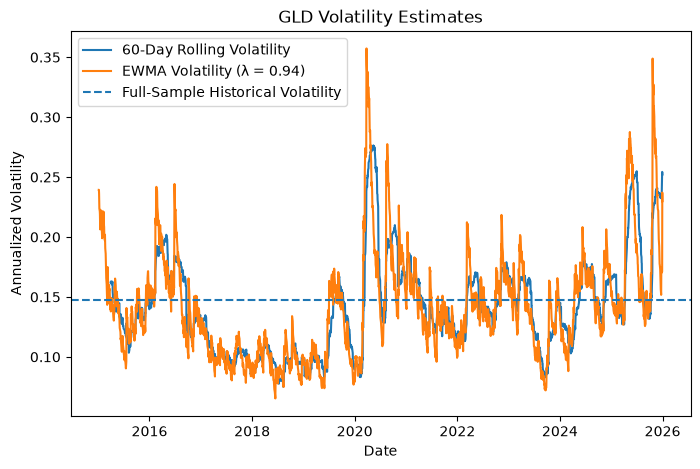

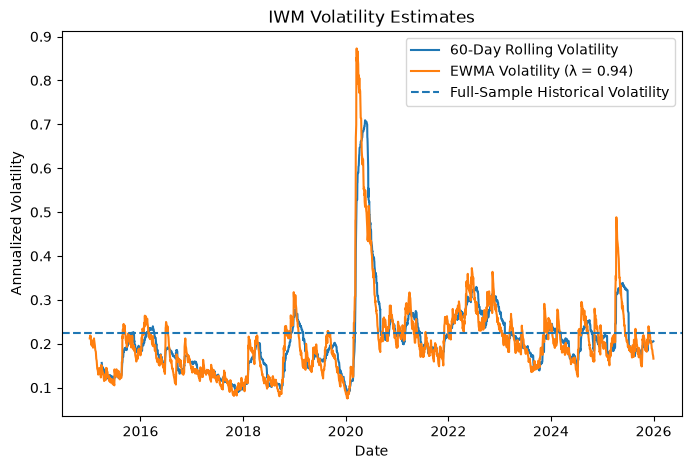

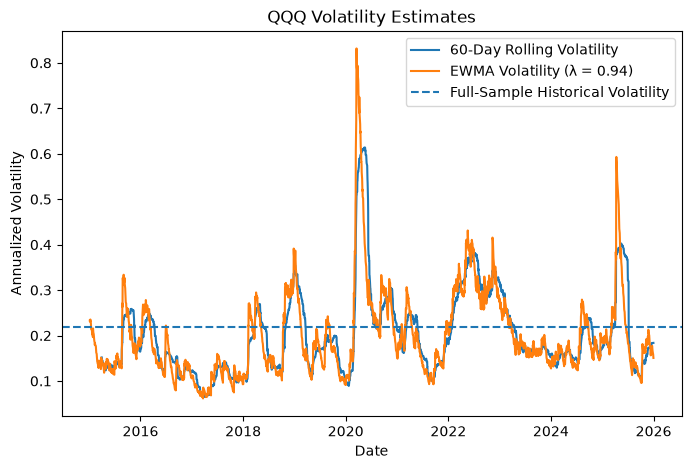

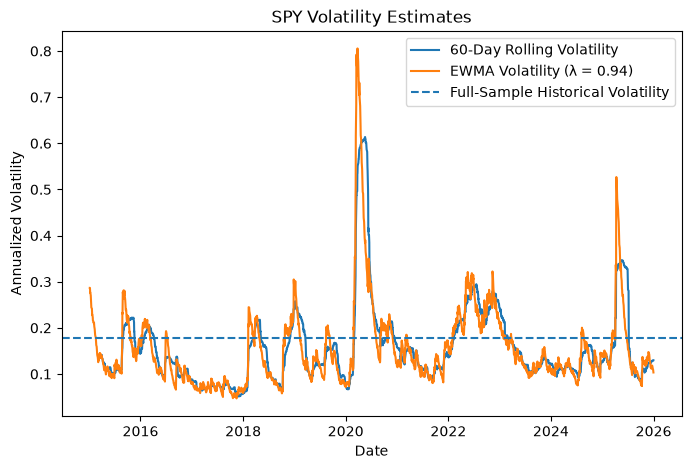

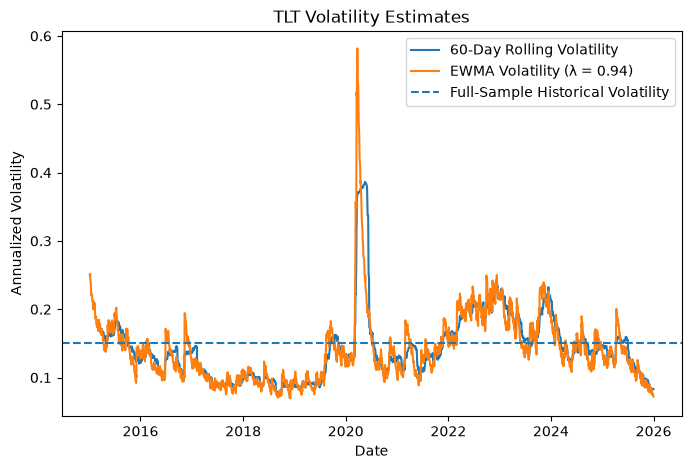

In [11]:
for ticker in returns.columns:
    plt.figure(figsize=(8,5))
    plt.plot(
        rolling_volatility_table[ticker] * np.sqrt(252),
        label="60-Day Rolling Volatility"
    )
    
    plt.plot(
        ewma_table[f"{ticker}_annualized_volatility"],
        label="EWMA Volatility (λ = 0.94)"
    )

    plt.axhline(
        y=annualized_volatility[ticker],
        linestyle="--",
        label="Full-Sample Historical Volatility"
    )
    
    plt.title(f"{ticker} Volatility Estimates")
    plt.xlabel("Date")
    plt.ylabel("Annualized Volatility")
    plt.legend()

    plt.show()

## Key Observations

The volatility estimates vary depending on the estimation methodology.

- **Full-sample historical volatility** remains constant because all observations receive equal weight.
- **Rolling volatility** responds to changes in the recent volatility environment over the 60-day estimation window.
- **EWMA volatility** assigns greater weight to recent observations and therefore responds more quickly to volatility shocks.

The choice of volatility estimator is an important model assumption because it can materially affect subsequent portfolio volatility and Parametric VaR estimates.

The correlation analysis also demonstrates that diversification benefits depend on the dependence structure between assets. The equity ETFs exhibit substantial positive correlation, while TLT and GLD provide comparatively different return behavior.